In [1]:
from langchain_ollama import ChatOllama

model = ChatOllama(model="gpt-oss:120b-cloud")
print('Model is ready')


c:\Users\ak60492\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
[transformers] PyTorch was not found. Models won't be available and only tokenizers, configuration and file/data utilities can be used.


Model is ready


In [2]:
from langchain_community.tools import tool

@tool
def get_weather(city: str) -> str:
    """Get weather for a city"""
    return f"The weather in the city {city} is Sunny"

@tool
def get_stock_price(stock: str) -> str:
    """Returns the stock price for a given stock"""
    return f"The stock price of {stock} is 25.50"

print('Tools are ready')

Tools are ready


In [4]:
# STEP 1 - Define the central state of the application
from typing import Annotated, TypedDict
from langchain_core.messages import AnyMessage
from langgraph.graph.message import add_messages

# shopping cart application
class ShoppingCart(TypedDict):
    books_in_the_cart: list[str]
    location: str

# banking application state
class AccountDetails(TypedDict):
    accno: int
    name: str
    balance: float

class AgentState(TypedDict):
    messages: Annotated[list[AnyMessage], add_messages]

print('Graph State is ready')


Graph State is ready


In [5]:
# STEP 2 - Define your nodes
def call_llm(state:AgentState) -> dict:
    """One graph node: call the LLM using current messages."""
    response = model.invoke(state['messages'])
    return {"messages": [response]}


In [6]:
# STEP 3 - Bind nodes together using Edges
from langgraph.graph import StateGraph, START, END

simple_graph_builder = StateGraph(AgentState)

# Node registration
simple_graph_builder.add_node("assistant", call_llm)

# Add edges to nodes
simple_graph_builder.add_edge(START, "assistant")
simple_graph_builder.add_edge("assistant", END)

simple_graph = simple_graph_builder.compile()
print('Simpl graph is ready')

Simpl graph is ready


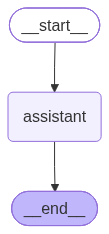

In [7]:
simple_graph

In [8]:
response = simple_graph.invoke({
    "messages": [
        {"role": "user", "content": "Which is the capital city of India?"}
    ]
})

response

{'messages': [HumanMessage(content='Which is the capital city of India?', additional_kwargs={}, response_metadata={}, id='83047536-812c-4e64-adaa-8056dcc058ed'),
  AIMessage(content='The capital city of India is **New\u202fDelhi**.', additional_kwargs={}, response_metadata={'model': 'gpt-oss:120b', 'created_at': '2026-09-17T04:45:11.852127102Z', 'done': True, 'done_reason': 'stop', 'total_duration': 314755784, 'load_duration': None, 'prompt_eval_count': 75, 'prompt_eval_duration': None, 'eval_count': 56, 'eval_duration': None, 'logprobs': None, 'model_name': 'gpt-oss:120b', 'model_provider': 'ollama'}, id='lc_run--01a0adae-d240-70b3-af3c-aa7aea2e0767-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 75, 'output_tokens': 56, 'total_tokens': 131})]}

In [9]:
response = simple_graph.invoke({
    "messages": [
        {"role": "user", "content": "How is the weather in Pune city today?"}
    ]
})

response

{'messages': [HumanMessage(content='How is the weather in Pune city today?', additional_kwargs={}, response_metadata={}, id='74ecb428-3266-43f7-9c2d-fa349cf44e17'),
  AIMessage(content='I’m not able to pull live weather data, so I can’t give you the exact temperature, humidity, or chance of rain for Pune at this very moment.  \n\n**Here’s what you can do to get the most up‑to‑date information:**\n\n| Method | How to use it | Typical update frequency |\n|--------|---------------|--------------------------|\n| **Weather apps** (e.g.,\u202fWeather.com, AccuWeather, Google Weather) | Open the app, type “Pune” or enable location services. | Every few minutes (often real‑time). |\n| **Smartphone widgets** | Add a weather widget to your home screen; most Android/iOS widgets auto‑refresh. | Real‑time. |\n| **Voice assistants** (Google Assistant, Siri, Alexa) | Say “Hey Google, what’s the weather in Pune?” | Instant. |\n| **Local news websites** (Times of India – Pune edition, Maharashtra TV ch